In [1]:
import os
import folium
from folium.plugins import HeatMap, MarkerCluster
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

In [4]:
# -------------------------------------------------------------------------
# 0. SETUP & DIRECTORIES
# -------------------------------------------------------------------------
# Ensure output directory exists relative to notebook
output_dir = "../outputs"
os.makedirs(output_dir, exist_ok=True)

# Visual styling setup
sns.set_theme(style="whitegrid")
plt.rcParams.update({"font.sans-serif": "DejaVu Sans", "figure.dpi": 150})

In [16]:
# -------------------------------------------------------------------------
# 1. DATA WRANGLING & FEATURE ENGINEERING
# -------------------------------------------------------------------------
df = pd.read_csv("../data/calgary_traffic.csv")

# Standardize column headers
df.columns = df.columns.str.strip().str.lower()

# Parse timestamps
df["start_dt"] = pd.to_datetime(
    df["start_dt"], format="%Y/%m/%d %I:%M:%S %p", errors="coerce"
)

# Drop records missing critical coordinates or date
df = df.dropna(subset=["start_dt", "latitude", "longitude"])

# Temporal features
df["year"] = df["start_dt"].dt.year
df["month"] = df["start_dt"].dt.month
df["month_name"] = df["start_dt"].dt.strftime("%b")
df["day_of_week"] = df["start_dt"].dt.day_name()
df["day_name"] = df["start_dt"].dt.day_name()
df["hour"] = df["start_dt"].dt.hour
df["is_weekend"] = df["start_dt"].dt.dayofweek >= 5

# Categorize commute risk period
def assign_time_of_day(hour):
    if 7 <= hour <= 9:
        return "Morning Rush (7-9 AM)"
    elif 11 <= hour <= 13:
        return "Midday (11 AM-1 PM)"
    elif 16 <= hour <= 18:
        return "Evening Rush (4-6 PM)"
    elif 22 <= hour or hour <= 4:
        return "Late Night (10 PM-4 AM)"
    else:
        return "Off-Peak"

df["time_of_day"] = df["hour"].apply(assign_time_of_day)

# Standardize quadrant column name if present
quad_col = "quadrant" if "quadrant" in df.columns else "quad"
if quad_col in df.columns:
    df["quadrant_clean"] = df[quad_col].str.upper().str.strip()

print(f"Dataset successfully cleaned. Total valid records: {len(df):,}")

Dataset successfully cleaned. Total valid records: 55,942


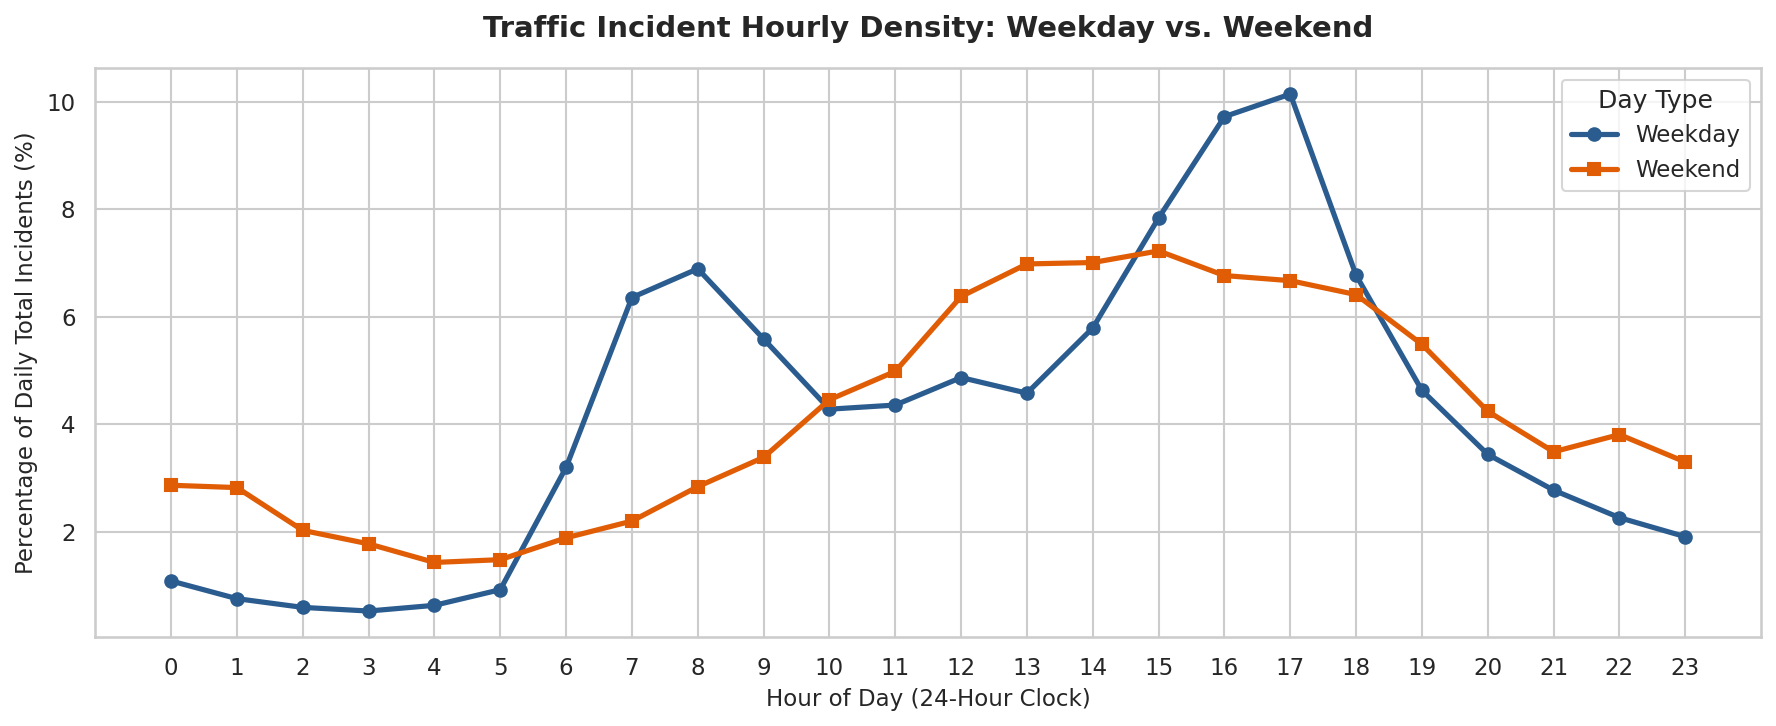

Saved: ../outputs/weekday_vs_weekend.png


In [13]:
# -------------------------------------------------------------------------
# CHART 1: WEEKDAY VS WEEKEND HOURLY COMMUTE DENSITY
# -------------------------------------------------------------------------
plt.figure(figsize=(12, 5))
hourly_counts = df.groupby(["hour", "is_weekend"]).size().unstack(fill_value=0)

# Normalize to percentage of total daily incidents to compare proportions
hourly_pct = hourly_counts.div(hourly_counts.sum(axis=0), axis=1) * 100

plt.plot(
    hourly_pct.index,
    hourly_pct[False],
    marker="o",
    linewidth=2.5,
    label="Weekday",
    color="#2b5c8f",
)
plt.plot(
    hourly_pct.index,
    hourly_pct[True],
    marker="s",
    linewidth=2.5,
    label="Weekend",
    color="#e05d06",
)

plt.title("Traffic Incident Hourly Density: Weekday vs. Weekend", fontsize=14, pad=15, weight="bold")
plt.xlabel("Hour of Day (24-Hour Clock)", fontsize=11)
plt.ylabel("Percentage of Daily Total Incidents (%)", fontsize=11)
plt.xticks(range(0, 24))
plt.legend(title="Day Type", frameon=True)
plt.tight_layout()

# SAVE FIRST, THEN SHOW (Prevents blank images)
fig1_path = os.path.join(output_dir, "weekday_vs_weekend.png")
plt.savefig(fig1_path, dpi=300, bbox_inches="tight")
plt.show()
print(f"Saved: {fig1_path}")


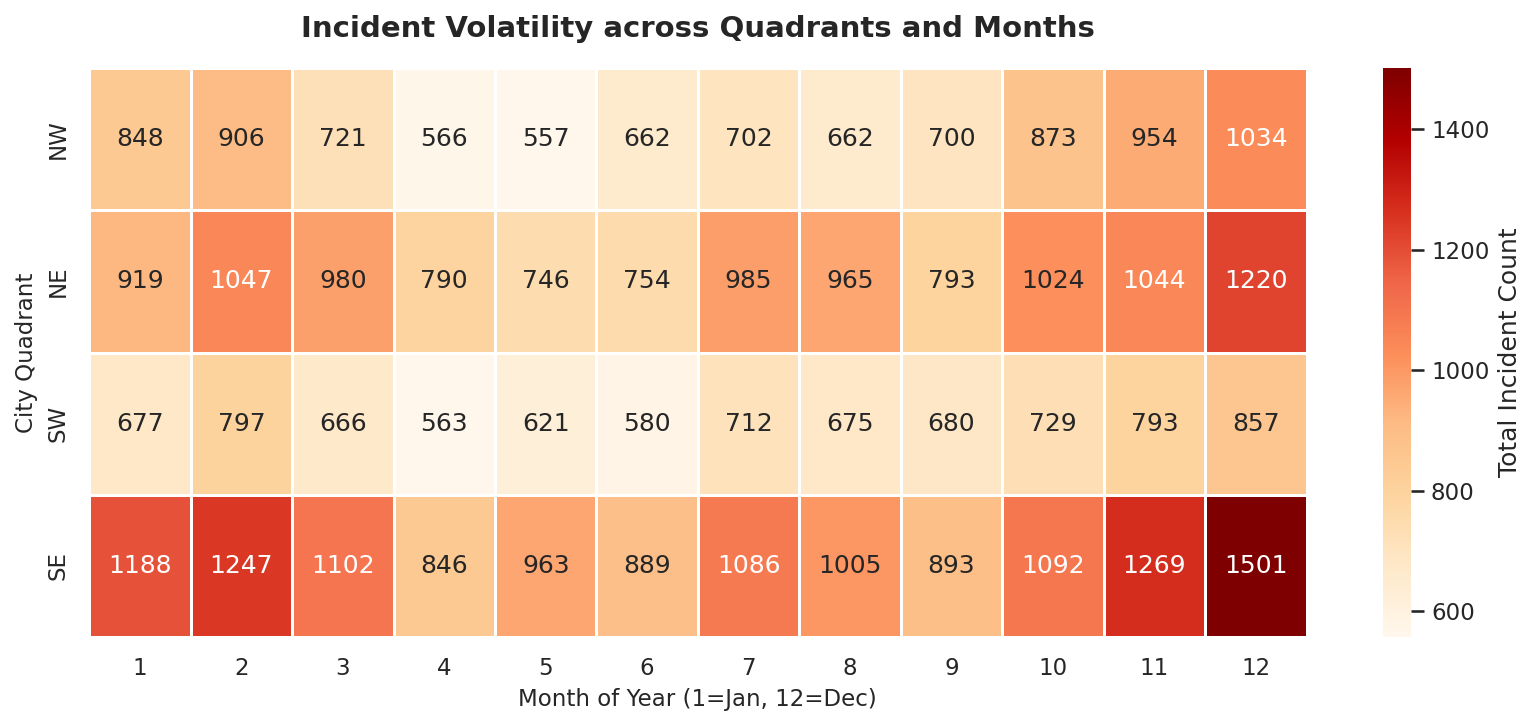

Saved: ../outputs/quadrant_seasonality_heatmap.png


In [14]:
# -------------------------------------------------------------------------
# CHART 2: QUADRANT X MONTHLY INCIDENT HEATMAP
# -------------------------------------------------------------------------
if "quadrant_clean" in df.columns:
    quad_month = df.pivot_table(
        index="quadrant_clean", columns="month", values="start_dt", aggfunc="count"
    )
    # Target 4 primary city quadrants
    valid_quads = ["NW", "NE", "SW", "SE"]
    quad_month = quad_month.reindex(valid_quads).dropna()

    plt.figure(figsize=(11, 5))
    sns.heatmap(
        quad_month,
        cmap="OrRd",
        annot=True,
        fmt="g",
        linewidths=0.5,
        cbar_kws={"label": "Total Incident Count"},
    )
    plt.title("Incident Volatility across Quadrants and Months", fontsize=14, pad=15, weight="bold")
    plt.xlabel("Month of Year (1=Jan, 12=Dec)", fontsize=11)
    plt.ylabel("City Quadrant", fontsize=11)
    plt.tight_layout()

    fig2_path = os.path.join(output_dir, "quadrant_seasonality_heatmap.png")
    plt.savefig(fig2_path, dpi=300, bbox_inches="tight")
    plt.show()
    print(f"Saved: {fig2_path}")

In [17]:
# -------------------------------------------------------------------------
# ENHANCED GEOSPATIAL MAP WITH HEATMAP & TOP HOTSPOTS
# -------------------------------------------------------------------------
# Center on Calgary
calgary_center = [51.0447, -114.0719]

# Create Map
m = folium.Map(location=calgary_center, zoom_start=11)

# Feature Group 1: Calibrated Heatmap
heatmap_group = folium.FeatureGroup(name="Incident Density (Heatmap)")
# Sample points if dataset > 30k for crisp rendering performance
sample_data = df.sample(n=min(25000, len(df)), random_state=42)
heat_data = sample_data[["latitude", "longitude"]].values.tolist()

HeatMap(
    heat_data,
    radius=8,          # Lower radius prevents single big color blob
    blur=12,           # Smooth transitions
    min_opacity=0.3,
).add_to(heatmap_group)
heatmap_group.add_to(m)

# Feature Group 2: Top 10 High-Collision Intersections
hotspot_group = folium.FeatureGroup(name="Top 10 Incident Hotspots")

location_col = "incident info" if "incident info" in df.columns else "description"

top_10 = (
    df.groupby([location_col, "latitude", "longitude"])
    .agg(
        total_incidents=("start_dt", "count"),
        peak_hour=("hour", lambda x: x.mode()[0] if not x.empty else "N/A"),
    )
    .reset_index()
    .sort_values(by="total_incidents", ascending=False)
    .head(10)
)

for rank, row in enumerate(top_10.iterrows(), 1):
    # row is a tuple of (index, Series)
    data = row[1]
    
    popup_content = f"""
    <div style="font-family: Arial, sans-serif; width: 200px;">
        <h4 style="margin:0 0 5px 0; color:#d9534f;">#{rank} Hotspot</h4>
        <b>Location:</b> {data[location_col]}<br>
        <b>Total Incidents:</b> {int(data['total_incidents']):,}<br>
        <b>Peak Risk Hour:</b> {data['peak_hour']}:00
    </div>
    """
    folium.CircleMarker(
        location=[data["latitude"], data["longitude"]],
        radius=10,
        popup=folium.Popup(popup_content, max_width=250),
        color="#b30000",
        fill=True,
        fill_color="#e31a1c",
        fill_opacity=0.85,
        weight=2,
    ).add_to(hotspot_group)

hotspot_group.add_to(m)

# Layer controls so user can toggle Heatmap vs Hotspots
folium.LayerControl(collapsed=False).add_to(m)

# Custom On-Map Floating Legend HTML
legend_html = """
<div style="
    position: fixed; 
    bottom: 30px; left: 30px; width: 220px; height: 130px; 
    background-color: white; z-index:9999; font-size:12px;
    border:2px solid #ccc; border-radius:8px; padding: 10px;
    box-shadow: 2px 2px 6px rgba(0,0,0,0.2);
    font-family: sans-serif;
">
    <p style="margin-top:0; font-weight:bold; margin-bottom:8px;">Legend</p>
    <div><i style="background: red; width: 12px; height: 12px; display: inline-block; border-radius: 50%; margin-right: 5px;"></i> Top 10 Intersection Hotspot</div>
    <div style="margin-top:6px;"><span style="background: linear-gradient(to right, blue, green, yellow, red); width: 80px; height: 10px; display: inline-block; margin-right: 5px;"></span> Density (Low → High)</div>
    <p style="margin-top:8px; margin-bottom:0; font-size:10px; color:#666;">Source: City of Calgary Open Data</p>
</div>
"""
m.get_root().html.add_child(folium.Element(legend_html))

# Save Map File
map_path = os.path.join(output_dir, "calgary_traffic_density_map.html")
m.save(map_path)
print(f"Interactive Map Saved: {map_path}")

Interactive Map Saved: ../outputs/calgary_traffic_density_map.html


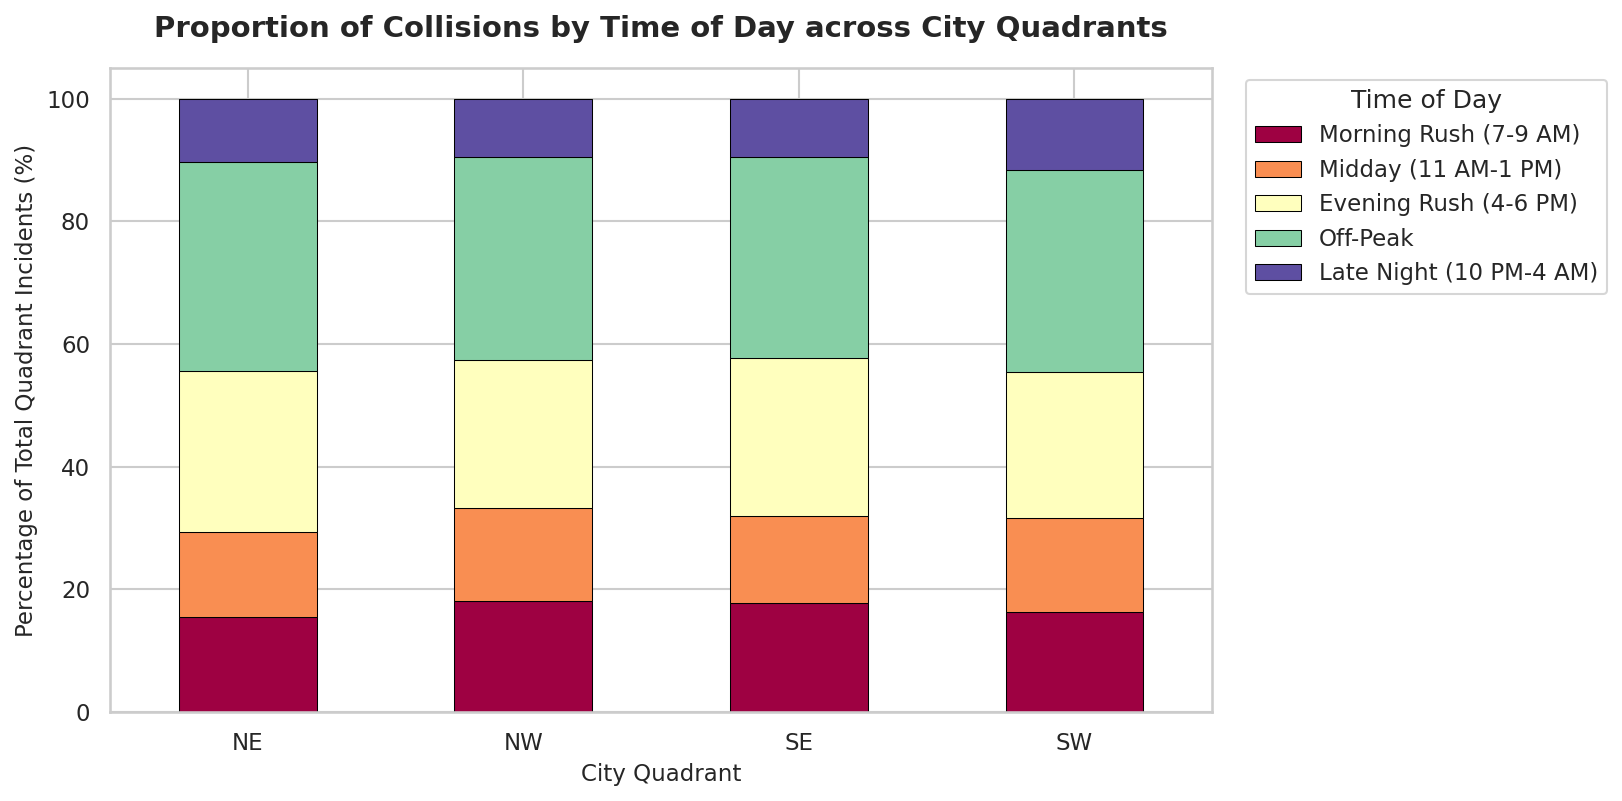

Saved: ../outputs/time_of_day_by_quadrant.png


In [7]:
# -------------------------------------------------------------------------
# CHART 3: TIME OF DAY DISTRIBUTION BY CITY QUADRANT
# -------------------------------------------------------------------------
if "quadrant_clean" in df.columns:
    # Filter to main 4 city quadrants
    valid_quads = ["NW", "NE", "SW", "SE"]
    quad_df = df[df["quadrant_clean"].isin(valid_quads)]

    # Define logical order for time of day categories
    tod_order = [
        "Morning Rush (7-9 AM)",
        "Midday (11 AM-1 PM)",
        "Evening Rush (4-6 PM)",
        "Off-Peak",
        "Late Night (10 PM-4 AM)",
    ]

    # Create cross-tabulation of Quadrant vs Time of Day
    tod_quad = pd.crosstab(
        quad_df["quadrant_clean"],
        quad_df["time_of_day"],
        normalize="index",  # Normalize by quadrant (rows sum to 100%)
    )[tod_order] * 100

    # Plot stacked bar chart
    fig, ax = plt.subplots(figsize=(11, 5.5))
    tod_quad.plot(
        kind="bar",
        stacked=True,
        colormap="Spectral",
        edgecolor="black",
        linewidth=0.5,
        ax=ax,
    )

    plt.title(
        "Proportion of Collisions by Time of Day across City Quadrants",
        fontsize=14,
        pad=15,
        weight="bold",
    )
    plt.xlabel("City Quadrant", fontsize=11)
    plt.ylabel("Percentage of Total Quadrant Incidents (%)", fontsize=11)
    plt.xticks(rotation=0)
    plt.legend(
        title="Time of Day",
        bbox_to_anchor=(1.02, 1),
        loc="upper left",
        frameon=True,
    )
    plt.tight_layout()

    # SAVE FIRST, THEN SHOW
    fig3_path = os.path.join(output_dir, "time_of_day_by_quadrant.png")
    plt.savefig(fig3_path, dpi=300, bbox_inches="tight")
    plt.show()
    print(f"Saved: {fig3_path}")

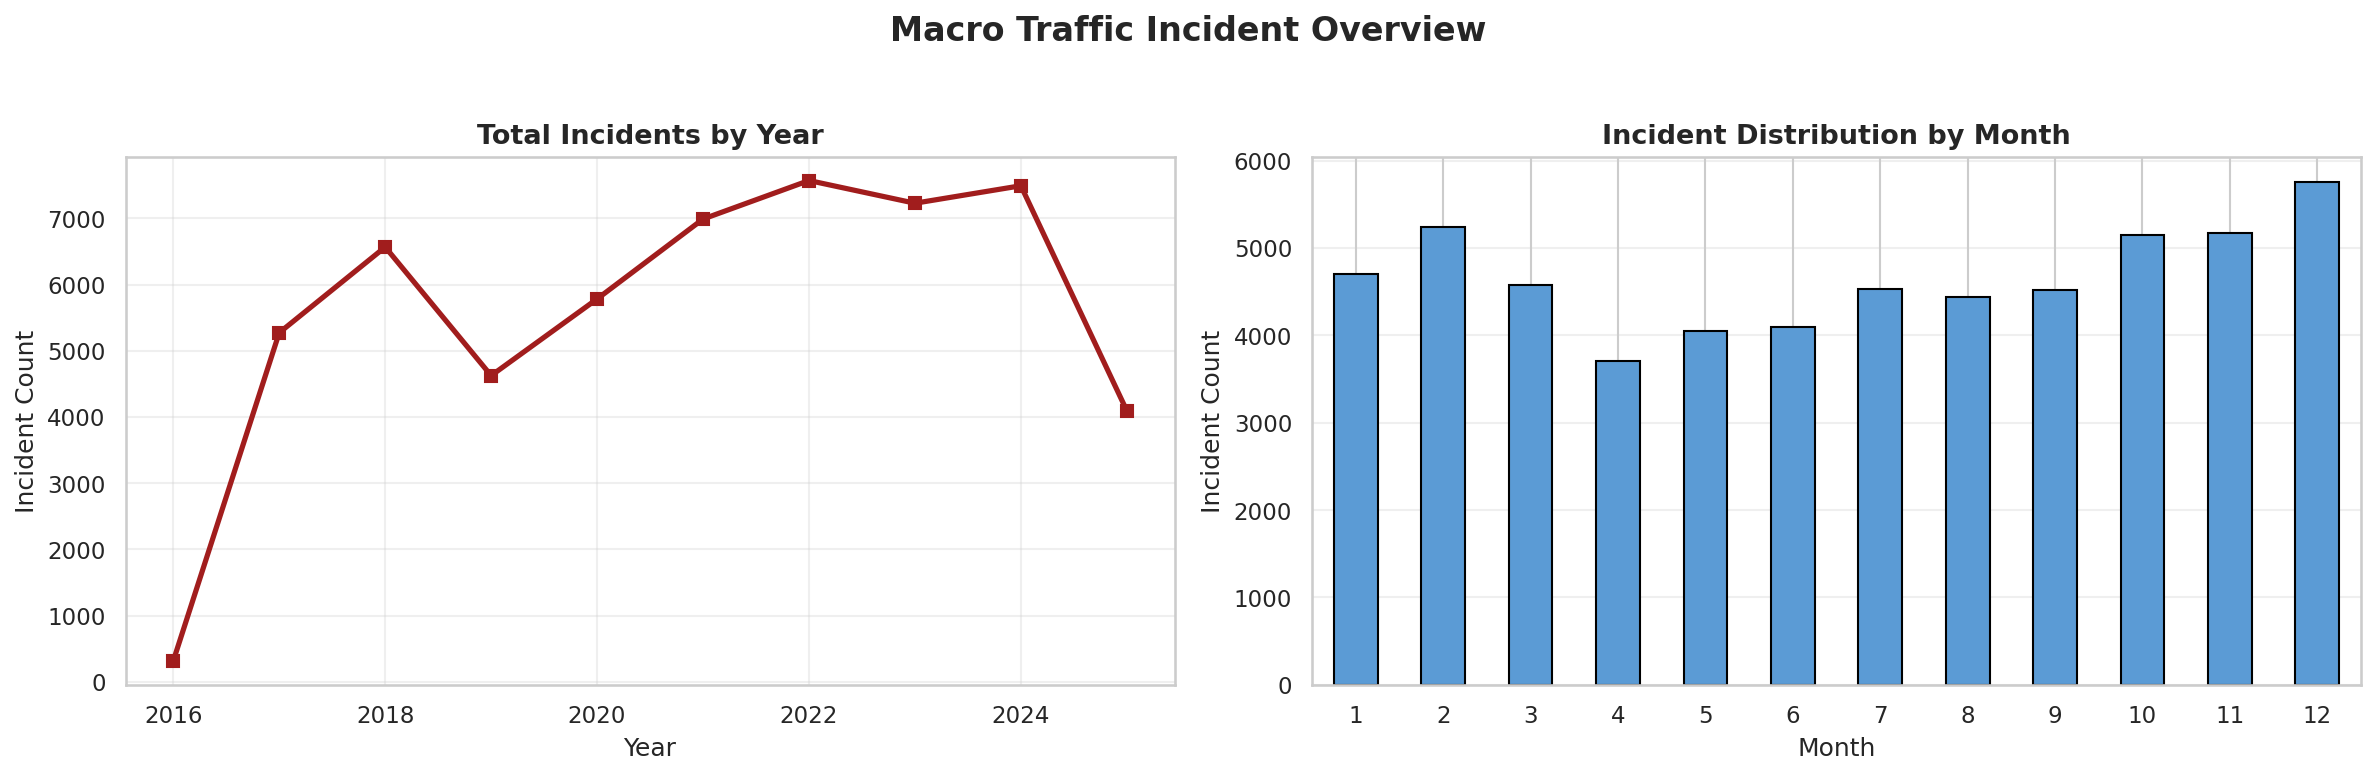

In [8]:
# -------------------------------------------------------------------------
# CHART 4. MACRO ANALYTICS DASHBOARD (YEARLY & MONTHLY TRENDS)
# -------------------------------------------------------------------------
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))

# Left Subplot: Yearly totals
df.groupby("year").size().plot(
    kind="line", marker="s", color="#a11d1d", linewidth=2.5, ax=ax1
)
ax1.set_title("Total Incidents by Year", fontsize=13, weight="bold")
ax1.set_xlabel("Year")
ax1.set_ylabel("Incident Count")
ax1.grid(True, alpha=0.3)

# Right Subplot: Monthly distribution
df.groupby("month").size().plot(
    kind="bar", color="#5b9bd5", edgecolor="black", ax=ax2
)
ax2.set_title("Incident Distribution by Month", fontsize=13, weight="bold")
ax2.set_xlabel("Month")
ax2.set_ylabel("Incident Count")
ax2.set_xticklabels(range(1, 13), rotation=0)
ax2.grid(axis="y", alpha=0.3)

plt.suptitle("Macro Traffic Incident Overview", fontsize=16, y=1.03, weight="bold")
plt.tight_layout()

# Save before showing
fig_macro_path = os.path.join(output_dir, "macro_analytics_dashboard.png")
plt.savefig(fig_macro_path, dpi=300, bbox_inches="tight")
plt.show()

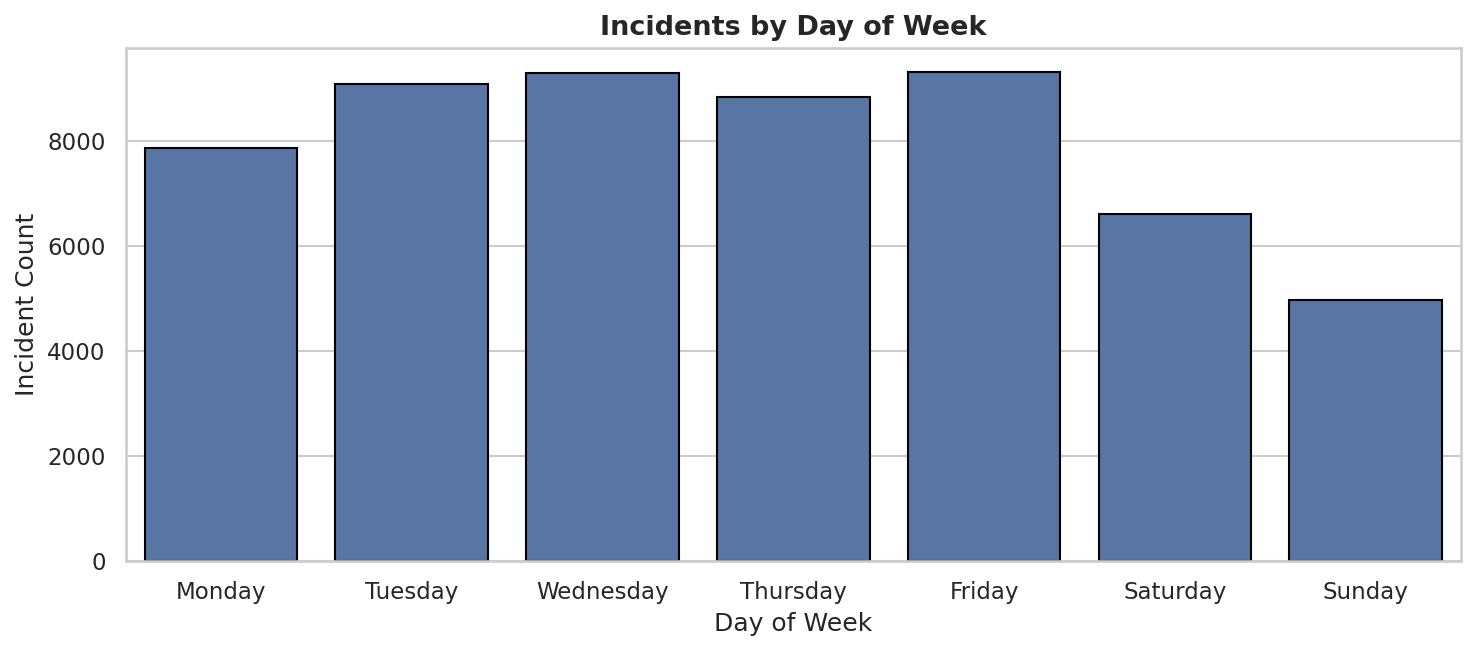

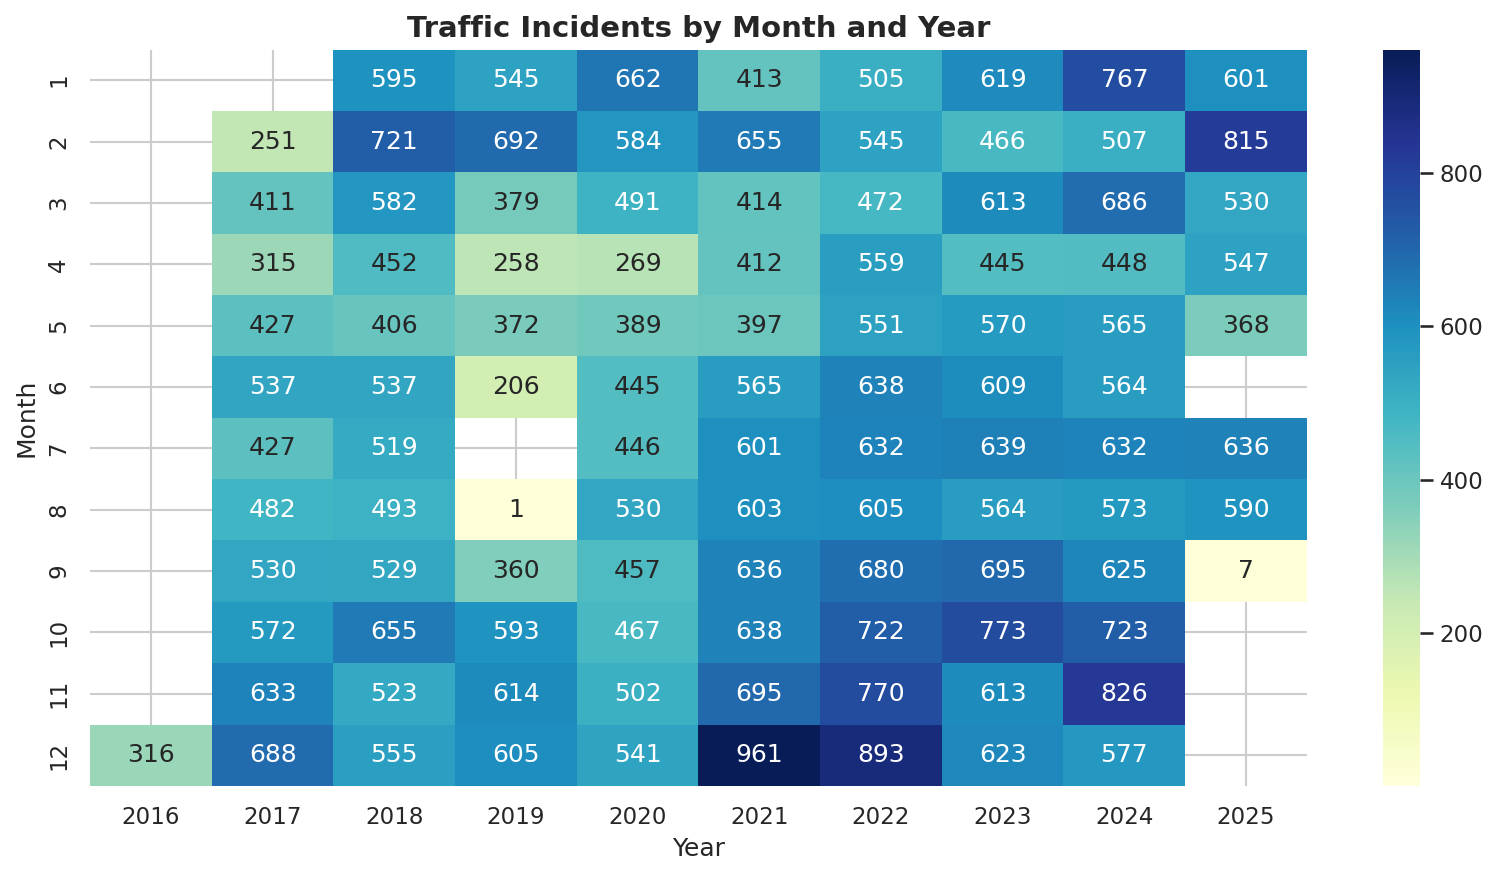

In [9]:
# -------------------------------------------------------------------------
# CHART 5. DAY OF WEEK & MONTHLY HEATMAP
# -------------------------------------------------------------------------
plt.figure(figsize=(10, 4.5))
day_order = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday",
]
sns.countplot(
    data=df, x="day_of_week", order=day_order, edgecolor="black"
)
plt.title("Incidents by Day of Week", fontsize=13, weight="bold")
plt.xlabel("Day of Week")
plt.ylabel("Incident Count")
plt.tight_layout()

fig_dow_path = os.path.join(output_dir, "incidents_by_day_of_week.png")
plt.savefig(fig_dow_path, dpi=300, bbox_inches="tight")
plt.show()

# Month vs Year Heatmap
pivot_table = df.pivot_table(
    index="month", columns="year", values=location_col, aggfunc="count"
)
plt.figure(figsize=(11, 6))
sns.heatmap(pivot_table, annot=True, fmt="g", cmap="YlGnBu")
plt.title("Traffic Incidents by Month and Year", fontsize=14, weight="bold")
plt.xlabel("Year")
plt.ylabel("Month")
plt.tight_layout()

fig_pivot_path = os.path.join(output_dir, "heatmap_month_vs_year.png")
plt.savefig(fig_pivot_path, dpi=300, bbox_inches="tight")
plt.show()

/var/folders/n4/6kvzlmwd40q_8_yf3j7hxx080000gn/T/ipykernel_28584/4206021538.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


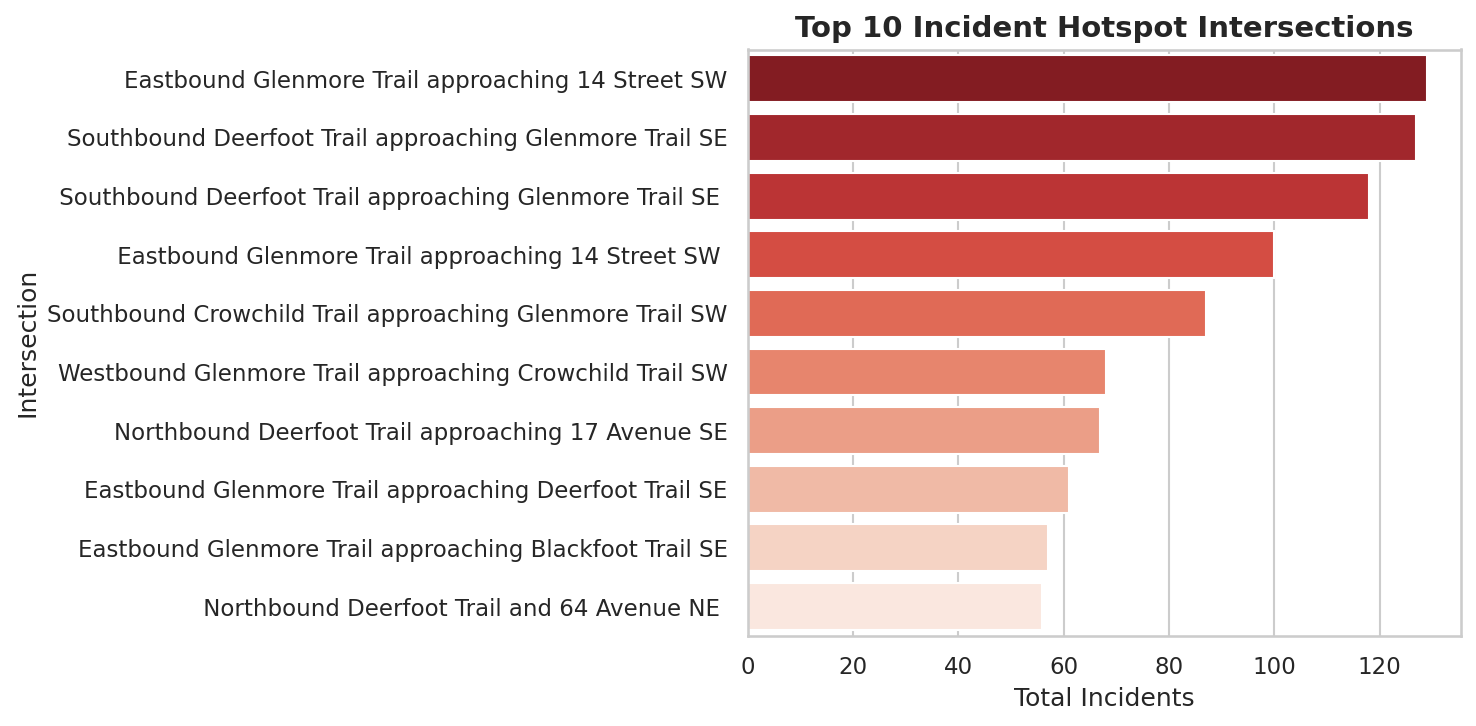

In [10]:
# -------------------------------------------------------------------------
# CHART 6. TOP 10 INTERSECTIONS
# -------------------------------------------------------------------------
top_intersections = (
    df[location_col]
    .value_counts()
    .head(10)
    .reset_index()
    .rename(columns={location_col: "Intersection", "count": "Incidents"})
)

plt.figure(figsize=(10, 5))
sns.barplot(
    data=top_intersections, x="Incidents", y="Intersection", palette="Reds_r"
)
plt.title("Top 10 Incident Hotspot Intersections", fontsize=14, weight="bold")
plt.xlabel("Total Incidents")
plt.tight_layout()

fig_top10_path = os.path.join(output_dir, "top_10_intersections.png")
plt.savefig(fig_top10_path, dpi=300, bbox_inches="tight")
plt.show()

In [11]:
print("\n--- Key Insights ---")
print(f"Total Clean Records Analyzed: {len(df):,}")
print(f"Most Frequent Incident Day: {df['day_of_week'].mode()[0]}")
print(f"Peak Hourly Commute Crash Time: {df['hour'].mode()[0]}:00")

incidents_by_month = df.groupby("month").size()
peak_month = incidents_by_month.idxmax()
print(f"Peak Incident Month: Month {peak_month} ({incidents_by_month[peak_month]:,} incidents)")

traffic_hotspot = top_intersections["Intersection"].iloc[0]
print(f"Primary City Hotspot: {traffic_hotspot}")


--- Key Insights ---
Total Clean Records Analyzed: 55,942
Most Frequent Incident Day: Friday
Peak Hourly Commute Crash Time: 17:00
Peak Incident Month: Month 12 (5,759 incidents)
Primary City Hotspot: Eastbound Glenmore Trail approaching 14 Street SW
